## IMPORTING LIBRARIES AND LOADING DATA

In [1]:
#!pip install mplsoccer hyperopt shap xgboost lightgbm imbalanced-learn

In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
%reload_ext autoreload

In [54]:
# System imports

from pathlib import Path
import sys
import os
import pandas as pd
import numpy as np
from scipy import stats

# Define project directory for notebook
PROJECT_DIR = Path.cwd().parent  # Move to parent directory relative to notebooks
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'src'))

DATA_PATH = PROJECT_DIR / 'data' / 'shots_combined_2015_2016.csv'

# Imports from custom modules
from src.data_processing import load_data, clean_data, select_features
from src.feature_engineering import (transform_to_binary, analyze_categorical_variables, 
                              extract_xy, calculate_angles_distances, transform_body_part, 
                              analyze_freeze_frame, standardize_features, create_dummies,
                              transform_play_pattern)
from src.models import prepare_train_test_split, train_logistic_regression, train_random_forest, train_xgboost
from src.evaluation import evaluate_model
from src.visualization import (create_quantile_efficiency, plot_shot_accuracy_by_distance_and_y, 
                        visualize_shot_situation, plot_binary_features_comparison, 
                        plot_stacked_bar, plot_body_part_by_distance_quantile, 
                        plot_shot_success_heatmap, plot_shot_effectiveness_by_quantiles, 
                        plot_angle_distribution, plot_goalkeeper_distance_ratio_distribution, plot_xg_shap_summary,
                        plot_passes_in_sequence_effectiveness, plot_xg_scatter)

In [5]:
df = load_data(DATA_PATH)

Data loaded: (45667, 122)


The loaded dataset is highly extensive. It contains **45,719 observations** and **120 variables**. However, not all variables are related to shots. Therefore, I can now remove variables that have NaN values for all observations.

In [6]:
df_cleaned = clean_data(df)

Removed 80 columns with all NaN
New data dimensions: (45667, 42)
Remaining 42 columns:
- duration
- id
- index
- location
- match_id
- minute
- n_passes_in_sequence
- off_camera
- opponent
- out
- period
- play_pattern
- player
- player_id
- position
- possession
- possession_team
- possession_team_id
- related_events
- second
- shot_aerial_won
- shot_body_part
- shot_deflected
- shot_end_location
- shot_first_time
- shot_follows_dribble
- shot_freeze_frame
- shot_key_pass_id
- shot_one_on_one
- shot_open_goal
- shot_outcome
- shot_redirect
- shot_saved_off_target
- shot_saved_to_post
- shot_statsbomb_xg
- shot_technique
- shot_type
- team
- team_id
- timestamp
- type
- under_pressure


As a result of this operation, the dataset size decreased to **40 columns**. After reviewing the remaining variables, I was able to select those potentially relevant for the future model.

## INITIAL DATASET WITHOUT VARIABLE PROCESSING

In [7]:
features = [
    'shot_outcome', # target variable
    'under_pressure', 'location', 
    'shot_technique', 'shot_body_part',
    'shot_type', 'shot_first_time', 'shot_open_goal',
    'shot_one_on_one', 'shot_follows_dribble', 'shot_freeze_frame',
    'player_id', # for shot_body_part transformation
    'n_passes_in_sequence',
    'play_pattern',
]

df_shots = select_features(df_cleaned, features)

Selected 14 features
New data dimensions: (45667, 14)


For further processing, I selected the following variables:
- **shot_outcome** - target variable describing the result of the shot taken,
- **under_pressure** - binary variable: whether the shot was taken under opponent pressure,
- **location** - location - informational variable about shot location: coordinates x (0-120) and y (0-80),
- **shot_technique** - categorical variable,
- **shot_body_part** - categorical variable: body part used for the shot,
- **shot_type** - categorical variable: shot situation: 'open play', free kick, penalty, etc.,
- **shot_first_time** - binary variable: whether shot was taken first-time (without control),
- **shot_open_goal** - binary variable: whether shot was taken at 'open goal',
- **shot_one_to_one** - binary variable: whether shot was taken in 'one-on-one' situation,
- **shot_follows_dribble** - binary variable: whether shot was taken after dribbling,
- **shot_freeze_frame** - variable containing locations of other players at moment of shot,
- **player_id** - helper variable: player identification number.

## TRANSFORMING TARGET VARIABLE TO BINARY VARIABLE

The first step after defining the dataset was creating the target variable by transforming shot_outcome into a binary variable.

In [8]:
df_shots = transform_to_binary(df_shots, column='shot_outcome', positive_value='Goal')

Original distribution of shot_outcome:
shot_outcome
Off T               33.00
Blocked             24.69
Saved               23.51
Goal                10.30
Wayward              5.91
Post                 1.91
Saved Off Target     0.35
Saved to Post        0.34
Name: proportion, dtype: float64

Distribution of shot_outcome after transformation:
shot_outcome
0    89.7
1    10.3
Name: proportion, dtype: float64


Originally, the variable contained many categories. For me, however, only the distinction was important: **goal vs no goal**. Therefore, I assigned 1 to observations labeled "Goal" and 0 to the rest. As it turned out, only about **10% of all shots resulted in scoring a goal**. This aligns with a commonly observed phenomenon in football, where on average every 10th offensive action ends with a shot, and every 10th shot ends with a goal. As a result, barely 1% of offensive actions culminate in scoring a goal.

For a predictive model, such strong class imbalance is not beneficial (model bias toward the majority class). Therefore, **resampling** will be necessary before training the model.

##  INITIAL TRANSFORMATIONS AND DATA CLEANING

In [9]:
print(df_shots.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45667 entries, 0 to 45666
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   shot_outcome          45667 non-null  int32  
 1   under_pressure        12270 non-null  object 
 2   location              45667 non-null  object 
 3   shot_technique        45667 non-null  object 
 4   shot_body_part        45667 non-null  object 
 5   shot_type             45667 non-null  object 
 6   shot_first_time       14383 non-null  object 
 7   shot_open_goal        484 non-null    object 
 8   shot_one_on_one       2330 non-null   object 
 9   shot_follows_dribble  35 non-null     object 
 10  shot_freeze_frame     45233 non-null  object 
 11  player_id             45667 non-null  float64
 12  n_passes_in_sequence  45667 non-null  int64  
 13  play_pattern          45667 non-null  object 
dtypes: float64(1), int32(1), int64(1), object(11)
memory usage: 4.7+ MB
No

All variables considered as explanatory variables for the model are of "object" type. Therefore, transformations will need to be performed on them in the later preparation phase. Additionally, 5 variables have null values. However, according to documentation, these are not true missings: for variables *shot_first_time*, *shot_open_goal*, *shot_one_on_one*, *shot_follows_dribble* Null value is equivalent to False. For the *shot_freeze_frame variable*, it takes NaN values for penalties (it doesn't make sense to provide player positioning then). This assumption can be quickly confirmed:

In [10]:
df_shots['shot_type'][df_shots['shot_freeze_frame'].isna()].unique()

array(['Penalty'], dtype=object)

Indeed, NaN values in the *shot_freeze_frame* column occur only for penalties. The next step is to take a closer look at variables that are assumed to have categories.

In [11]:
categorical = [
    'under_pressure', 'shot_technique', 'shot_body_part',
    'shot_type', 'shot_first_time', 'shot_open_goal',
    'shot_one_on_one', 'shot_follows_dribble'
]

distribution = analyze_categorical_variables(df_shots, categorical)

Distribution for variable 'under_pressure':
under_pressure
NaN     73.13
True    26.87
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_technique':
shot_technique
Normal           75.88
Half Volley      15.00
Volley            6.89
Lob               0.88
Overhead Kick     0.57
Backheel          0.40
Diving Header     0.38
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_body_part':
shot_body_part
Right Foot    52.14
Left Foot     31.16
Head          16.45
Other          0.24
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_type':
shot_type
Open Play    94.27
Free Kick     4.64
Penalty       1.06
Corner        0.03
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_first_time':
shot_first_time
NaN     68.5
True    31.5
Name: 

- **under_pressure** - 27% of shots were taken under opponent pressure and 73% without. Both categories are sufficiently numerous, so I'm keeping the variable. It will be converted to a binary variable.

- **shot_technique** - many categories with the most numerous being "Normal" (76% of shots). I decided to transform the variable into a binary variable: normal_shot. For "Normal" category I'll assign value 1, and for others value 0 (volleys, acrobatic shots, etc.)

- **shot_body_part** - three relatively numerous categories (Right Foot, Left Foot, Head) and one (Other) representing only 2.5%. I'll keep the first three categories, but instead of raw Left/Right Foot data, this should also relate to dribbling or foot dominance prediction. I'll group the least numerous categories as "other"

- **shot_type** - contains 4 categories, with one strongly dominant (Open Play - 94%). I'm keeping Free Kick category representing nearly 5% of observations and removing Corner, as direct shots from corner kicks are very rare (less than 0.5% of observations). For this parameter I decided to keep Penalty in the next step, because despite low frequency (about 1% of shots) I know that most of them end with scoring a goal.

- **shot_first_time** - 31.5% of shots were taken first-time and 68.5% with control (or from standing ball). Categories of this variable are well balanced. Variable will be converted to binary variable.

- **shot_open_goal**, **shot_one_on_one**, **shot_follows_dribble** - strongly imbalanced variables: **shot_one_on_one** variable contains 5% True values, but due to information I'll be able to extract from **shot_freeze_frame** variable, I decided that like the other two variables, this one will also be removed from the dataset.

In [12]:
print("All shots: ")
result1 = analyze_categorical_variables(df_shots, ['shot_outcome'])
print("Penalties")
result2 = analyze_categorical_variables(df_shots[df_shots['shot_type']=='Penalty'], ['shot_outcome'])

All shots: 
Distribution for variable 'shot_outcome':
shot_outcome
0    89.7
1    10.3
Name: proportion, dtype: float64
--------------------------------------------------
Penalties
Distribution for variable 'shot_outcome':
shot_outcome
1    75.72
0    24.28
Name: proportion, dtype: float64
--------------------------------------------------


As I noted in the previous step, penalties, despite representing only 1% of shots, end in goals 75% of the time. Additionally, their nature (taken from the same point, no opponent positioning, etc.) means they could strongly distort model results (e.g., artificially inflating shot effectiveness from around the "11-meter" area). Therefore, I decided to remove observations labeled as *Penalty*.

In [13]:
df_shots = df_shots[df_shots['shot_type']!='Penalty']
result = analyze_categorical_variables(df_shots, ['shot_outcome'])

Distribution for variable 'shot_outcome':
shot_outcome
0    90.41
1     9.59
Name: proportion, dtype: float64
--------------------------------------------------


After this operation, there was a slight decrease in the share of goals, which currently represent about **9.6% of all shots**.

### Continuous Variables

#### Coordinates - distance and shot angle

Coordinates of the point from which the shot was taken are encoded in the **location** variable in format [x, y]. The pitch has dimensions **120x80** (important not to treat this as meters or yards, as pitches have different dimensions and this is just a standardized pitch size proposed by StatsBomb) and the direction of attack runs from x=0 to x=120 (opponent's goal). Therefore, to calculate the distance from goal, or rather from the end line, the shot was taken from, a transformation to *distance_to_end_line* (120-x) will need to be performed.

In [14]:
df_shots = extract_xy(df_shots)
print(df_shots[['x', 'y', 'distance_to_end_line']].head())

       x     y  distance_to_end_line
0  112.0  35.7                   8.0
1   96.1  19.5                  23.9
2  110.3  41.2                   9.7
4  110.5  23.4                   9.5
5  104.7  56.0                  15.3


Visualizing shots based on coordinates is problematic because sectors on the pitch are unequal in number, and even strongly imbalanced. There must be more shots from close and central positions than those from distant and more lateral areas. Additionally, the data may contain outliers, e.g., when bold shots from 40-50 meters appear or attempts to place the ball in the net when striking from near the sidelines of the pitch. To mitigate these problems, I decided to divide shots into equal-sized quantiles.

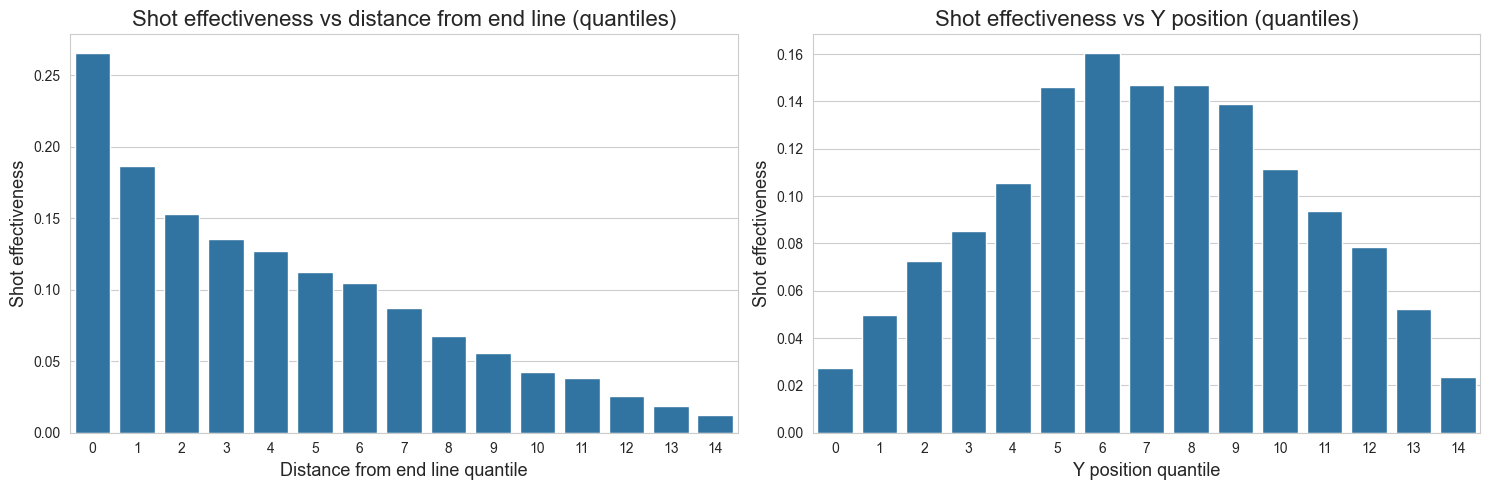

In [15]:
# Przygotowanie danych
eff_by_distance = create_quantile_efficiency(df_shots, 'distance_to_end_line', 'shot_outcome')
eff_by_y = create_quantile_efficiency(df_shots, 'y', 'shot_outcome')

fig, ax = plot_shot_accuracy_by_distance_and_y(eff_by_distance, eff_by_y)

Thanks to using quantiles we clearly see that shot effectiveness decreases with increasing distance from the end line. For the first quantile it's over 25%, for the seventh slightly over 10%, and for the last about 1-2%. A clear pattern is also visible for the effectiveness chart relative to pitch width (y coordinate). Shots taken from central positions are characterized by over 14% effectiveness, while those from side positions are below 5%.

Coordinates x (or rather 120-x) and y seem to be good differentiating variables. However, two more intuitive measures can be defined:
- **distance** - distance from the point where shot was taken (x,y) to goal center (120,40)
- **angle** - angle formed between lines connecting shot point (x,y) with goal posts (120,36 and 120,44). This measure describes how "large" the goal appears from the shooter's viewpoint. It will probably be strongly **negatively correlated with distance** variable, as angle will decrease with increasing distance.

In [16]:
df_shots = calculate_angles_distances(df_shots)

In [17]:
df_shots[['distance', 'angle']].describe()

,distance,angle
count,45181.000000,45181.000000
mean,19.519204,24.873237
std,8.704365,15.360805
min,0.632456,0.000000
25%,12.379418,14.860758
50%,19.027612,19.278945
75%,25.927784,30.401229
max,86.137100,180.000000


**Distance** variable takes values from 0.63 (very close shot) to 88.8 (shot from distance greater than pitch width). Average shot distance is about 19.5 units and almost coincides with median of 19 units. For shot **angle**, values are around 24.9 degrees while median is lower at 19.3 degrees.

Looking at descriptive statistics of angle variable, one can hypothesize that it's strongly right-skewed. This is evidenced by: 
- mean higher than median,
- quartile asymmetry, as differences between consecutive values are: 15°, 4.5°, 11° and 150° (!),
- relatively high standard deviation compared to quartile distribution

In the next part, I will take a closer look at the presumed asymmetry of the distribution.

### Categorical Variables

#### Body part - better_foot, worse_foot, head

Raw data contained in the **body_part** variable may have limited predictive power, due to the fact that different players have different dominant feet, and consequently some of them will prefer shots with the right foot, and some with the left. StatsBomb data does not contain information about which foot is preferred or dominant for a player. Therefore, I decided to check for each player which foot they used for more shots and consider that foot as their dominant one. In cases where a player took an equal number of shots with both feet, I decided to classify them as right-footed, as there are significantly more such players than left-footed ones. I assigned the new data to the **refined_body_part** variable.

In [18]:
df_shots = transform_body_part(df_shots)

Distribution of dominant foot among players:
foot_type
dominant_right    67.08
dominant_left     32.92
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of shots by type:
refined_body_part
better_foot    66.23
worse_foot     17.11
head           16.67
Name: proportion, dtype: float64


After conducting the above classification, it turned out that approximately 67% of players in the dataset are right-footed, while 33% are left-footed players. After applying feature engineering and creating **refined_body_part**, I obtained a new percentage distribution of shots: 66% of shots were taken with the better foot, 17% with the worse foot, and also about 17% were headers. In accordance with previous arrangements, I removed observations labeled "Others" as they represented only 0.24% of observations.

#### Transformation to Binary Variables

In accordance with previous assumptions, I transform some variables (**under_pressure**, **normal_shot**, **shot_first_time**, **open_play_shot**) into binary variables. Meanwhile, I remove observations with Corner value for the **shot_type** variable from the dataset (only 0.02% of observations).

In [19]:
# Transform variables to binary
df_shots = transform_to_binary(df_shots, 'under_pressure', positive_value=True, display_distribution=False)
df_shots = transform_to_binary(df_shots, 'shot_first_time', positive_value=True, display_distribution=False)

# Create new binary variables based on other columns
# For shot_technique -> normal_shot
# For shot_type -> open_play_shot
df_shots['normal_shot'] = np.where(df_shots['shot_technique'] == 'Normal', 1, 0)
df_shots['open_play_shot'] = np.where(df_shots['shot_type'] == 'Open Play', 1, 0)

# Filter corner kicks (only 0.02% of observations)
df_shots = df_shots[df_shots['shot_type'] != 'Corner']

# Reset index
df_shots = df_shots.reset_index(drop=True)

#### Transforming shot_freeze_frame into defenders_in_path and goalkeeper_in_path

Useful information can be extracted from the **shot_freeze_frame** variable. It contains the coordinates of player locations at the moment the shot was taken. This makes it possible to determine how many defenders were in the goal area and whether the goalkeeper was in the path of the ball. I defined the area "in the goal area" as the triangle formed by the shooting player and the goal posts. If a defender or goalkeeper was in this triangle, I classified them as present on the shot line (since in practice they were blocking part of the goal from the shooter).

In [20]:
df_shots = analyze_freeze_frame(df_shots)

DEFENDERS ON SHOT LINE:
defenders_in_path
0    48.57
1    34.26
2    10.94
3     4.12
4     1.56
5     0.43
6     0.08
7     0.02
8     0.01
Name: proportion, dtype: float64

GOALKEEPER ON SHOT LINE:
goalkeeper_in_path
0     3.94
1    96.06
Name: proportion, dtype: float64

GOALKEEPER DISTANCE RATIO:
count    45057.000000
mean         0.220595
std          0.180774
min          0.004788
25%          0.103735
50%          0.167935
75%          0.264773
max          1.000000
Name: goalkeeper_distance_ratio, dtype: float64


The **defenders_in_path** variable takes values from 0 to 8. However, it's clear that smaller values significantly predominate. In nearly 49% of cases there was no defender in the shot path, in 34% of cases there was one defender, in 11% of actions two defenders, and in 4% of shots there were three defenders. The subsequent values are so few that I decided to **group them together with value 3**.

Meanwhile, the **goalkeeper_in_path** variable is a binary variable that takes value 1 when the goalkeeper was in the shot radius and 0 otherwise. In 96% of shots, the goalkeeper was positioned between the shooter and the goal.

The **goalkeeper_distance_ratio** variable (range: 0-1) measures how far the goalkeeper has advanced from the goal center toward the shooter. With a mean of 0.23, goalkeepers typically come off their line by about 23% of the shot distance to narrow the shooting angle. The distribution shows moderate variation (std = 0.18), with 75% of values below 0.26.

In [21]:
df_shots['defenders_in_path'] = np.where(df_shots['defenders_in_path'] >= 3, 3, df_shots['defenders_in_path'])

In [22]:
df_shots['log_passes_in_sequence'] = np.log1p(df_shots['n_passes_in_sequence'])

print(f"n_passes_in_sequence — skewness: {df_shots['n_passes_in_sequence'].skew():.3f}")
print(f"log_passes_in_sequence — skewness: {df_shots['log_passes_in_sequence'].skew():.3f}")
df_shots[['n_passes_in_sequence', 'log_passes_in_sequence']].describe()

n_passes_in_sequence — skewness: 2.217
log_passes_in_sequence — skewness: 0.092


,n_passes_in_sequence,log_passes_in_sequence
count,45057.000000,45057.000000
mean,5.480192,1.548247
std,5.680883,0.803972
min,0.000000,0.000000
25%,1.000000,0.693147
50%,4.000000,1.609438
75%,8.000000,2.197225
max,63.000000,4.158883


Low numbers of defenders on the shot path may seem unintuitive. It appears that shots taken into a crowd of defenders are quite common. However, it's worth considering the following arguments:

* **Dynamics of offensive actions** - Professional teams deliberately construct plays to isolate defenders and create space. A well-executed attack leads to situations where there are minimal opponents on the shot line.

* **Pitch geometry** - The space in front of the goal is limited, and attacking players move in a way that naturally stretches defensive formations. Each striker tries to find the so-called "gap" in the defense, which by definition means minimizing the number of defenders on the shot line.

As it turns out, attacking players place great emphasis on finding space, even momentarily, to take the cleanest shot possible. Of course, this is not always possible - much depends on how the opposing team defends.

To better illustrate the discussed situations, I also prepared visualizations showing shots collected in the analyzed dataset. By entering a random number from 0 to 45,107, you can see how the player positioning looked at the moment of the shot. It's noticeable that defenders were often close to the triangle marking the shot radius. This demonstrates that strikers indeed try to find the moment when the number of opponents on the shot line is minimal.

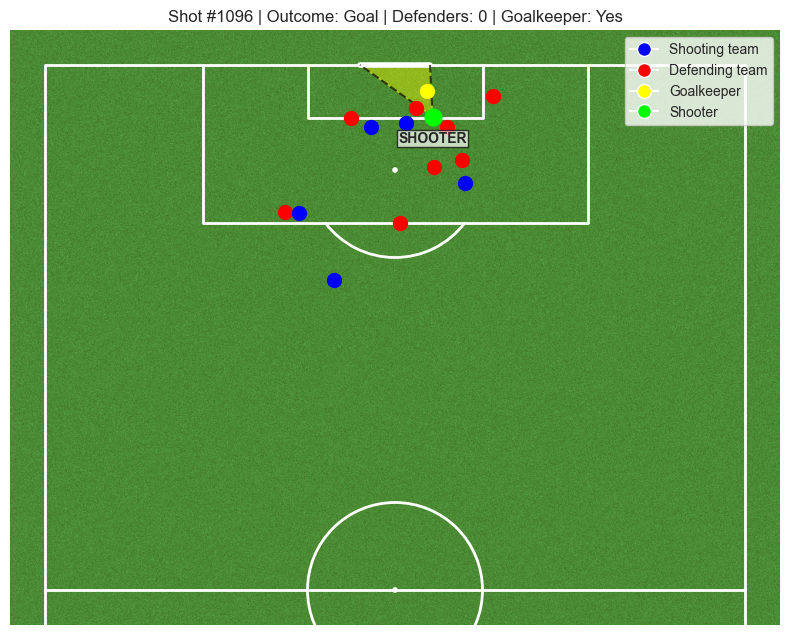

In [23]:
# Wizualizacja wybranego strzału
shot_index = 1096
fig, ax = visualize_shot_situation(df_shots, shot_index)

## Data Exploration

### Analysis of Binary Variables Relative to Target Variable

To better understand the data, I examined how shot effectiveness differs depending on the values of binary variables (0/1). For this purpose, I created column charts for the variables: **under_pressure**, **shot_first_time**, **normal_shot**, **open_play_shot**, **goalkeeper_in_path**. The left column illustrates the percentage effectiveness for observations that take value 0 for a given variable, while the right column shows effectiveness for shots labeled 1 for the given variable.

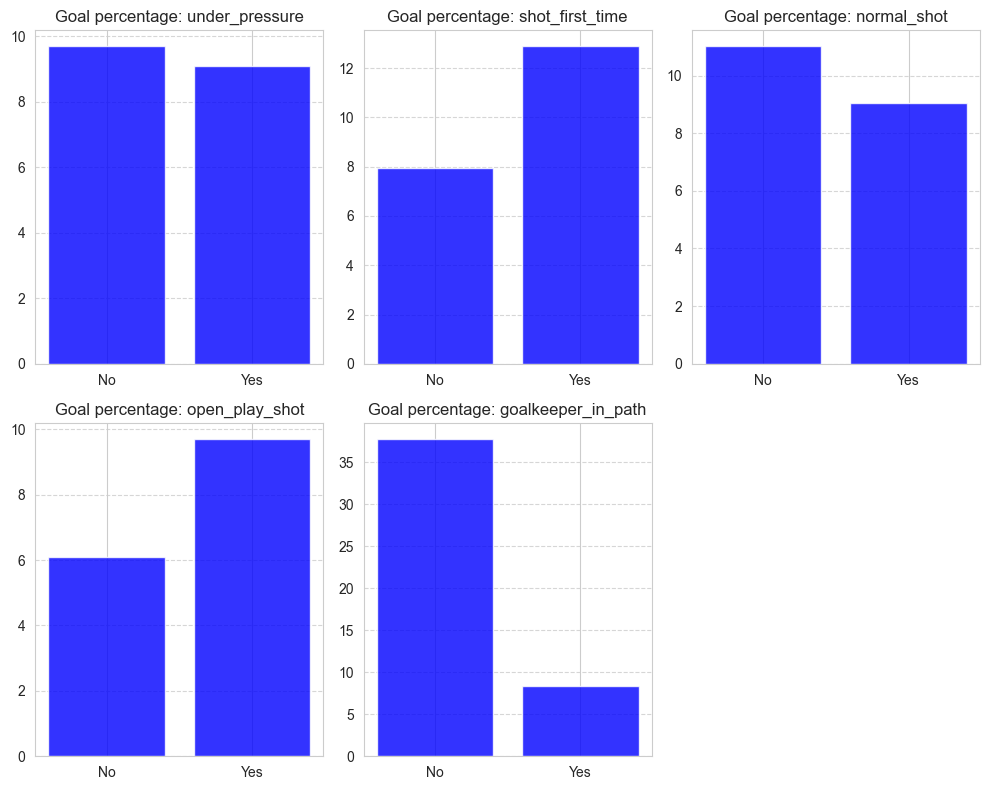

In [24]:
bin_features = ['under_pressure', 'shot_first_time', 'normal_shot', 'open_play_shot', 'goalkeeper_in_path']
fig, ax = plot_binary_features_comparison(df_shots, features=bin_features)

##### Under_pressure
- Shots without pressure have slightly higher effectiveness (approx. 9.8%) than shots under pressure (approx. 9.0%)
- The difference is relatively small, suggesting that opponent pressure has a moderate impact on effectiveness

##### Shot_first_time
- First-time shots have significantly higher effectiveness (approx. 12.5%) than shots preceded by ball control (approx. 8%)
- This may result from the element of surprise for the goalkeeper or the fact that first-time shots are usually taken in better situations

##### Normal_shot
- Normal shots have higher effectiveness (approx. 10.7%) than shots executed with special techniques (approx. 8.9%)
- This suggests that simpler strikes are often more effective than acrobatic, more spectacular ones

##### Open_play_shot
- Shots from open play have higher effectiveness (approx. 9.7%) than direct free kick shots (approx. 6.0%)
- This result may be surprising, as set pieces are often considered good scoring opportunities, but on the other hand, both defenders and goalkeeper are better prepared for the shot

##### Goalkeeper_in_path
- Here we see the clearest difference: shots without a goalkeeper on the line have effectiveness of approx. 37.5%, while shots with a goalkeeper in the path only approx. 8.5%
- This confirms the crucial role of the goalkeeper in defending the goal - his presence in the shot path reduces the chance of a goal by more than four times

This analysis shows that for the xG model, a crucial variable may be the presence of a goalkeeper on the shot line. Other variables, such as first-time shots or normal shots, also have a noticeable impact on the probability of scoring a goal.

### Shot Effectiveness Analysis by Body Part *(refined_body_part)*

The next variable I decided to examine was **refined_body_part**. This variable contains three categories: *better_foot*, *worse_foot*, *head*. Intuition suggests that shots taken with the better foot should be significantly more effective than those taken with the weaker foot. Additionally, the dominant foot should rather guarantee more goals than headers, which are often taken from difficult situations, surrounded by many defenders.

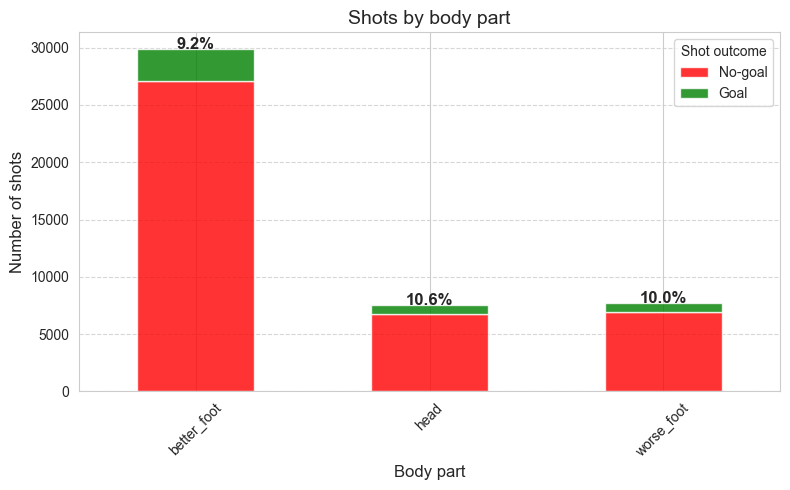

In [25]:
fig, ax = plot_stacked_bar(df_shots, 'refined_body_part', 'Shots by body part', 'Body part')

Most shots are taken with the better foot, while the share of shots taken with the worse foot is comparable to headers and together they represent about half the volume generated by better foot shots. Nevertheless, effectiveness for all body parts is similar and amounts to about 9-11%. This doesn't align with the intuitive approach. What could this result from? When striking with the better foot, players may be more inclined to take risks, i.e., shooting from greater distances or unprepared positions. Additionally, players with one strongly dominant foot may be easier to "read" by defenders and goalkeepers (though there are exceptions like legendary Arjen Robben and his cut to the left foot). To better understand this counterintuitive phenomenon, I created a stacked column chart showing the share of shots taken with each body part (of the three considered) depending on distance quantile.

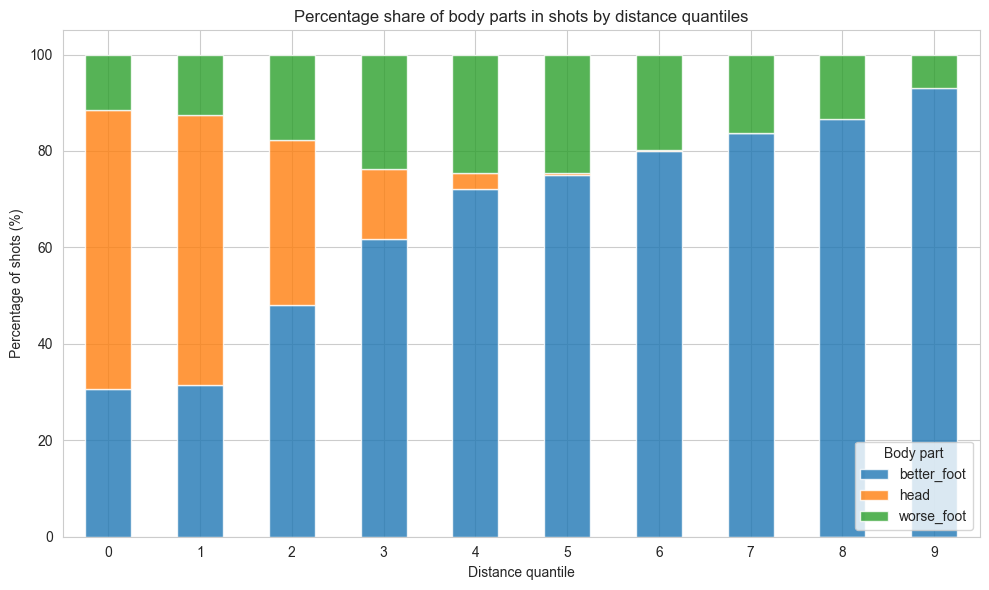

In [26]:
fig, ax = plot_body_part_by_distance_quantile(df_shots)

The above chart seems to confirm the thesis that shots with the better foot are usually taken from worse positions, from greater distances. After dividing shots into 10 equal quantiles, it turns out that in the lowest quantiles (best positions) the share of better foot shots is only about 30%, while in the last four quantiles this share exceeds 80%. We see the opposite situation with headers - close to 60% in the first quantile and a gradual decline to residual values in the 6th quantile. In the case of worse foot shots, we see a small share (about 10-15%) in the first quantiles, which is caused by the large share of headers. However, along with the decline in this category's share, we see an increase in worse foot shots up to quantiles 4 and 5, when there is a gradual yielding to shots taken with the better foot. The above observation signals that although overall effectiveness is not differentiated for different body parts, together with the *distance* variable it may positively influence the model's predictive power.

### Analysis of Ordinal Variable *(defenders_in_path)*

Another factor that seems extremely important for shot effectiveness appears to be the number of defenders in the shot path (**defenders_in_path**). As I noted in the earlier part of the analysis, the vast majority of shots are taken in situations where there is no defender on this potential shot path (49% of observations) or there is only one (34% of observations). It therefore seems that for the shooter it is very important to minimize the number of opponents on the stretch between him and the goal. If this is indeed beneficial, the data should confirm it.

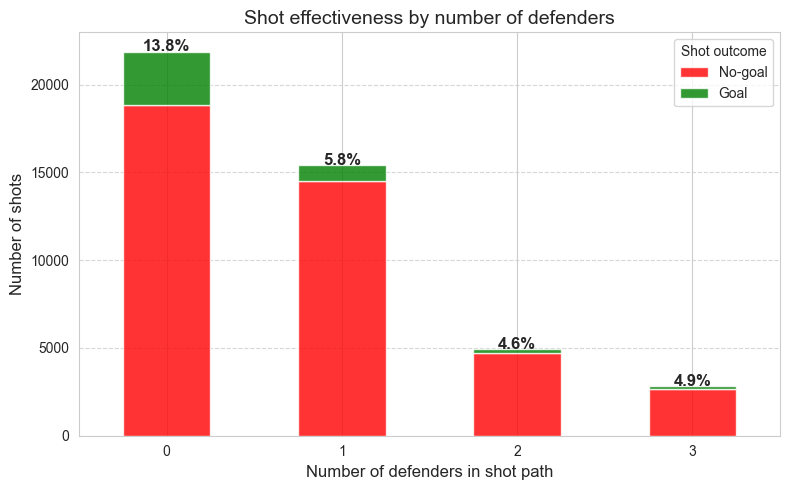

In [27]:
fig, ax = plot_stacked_bar(df_shots, 'defenders_in_path', 'Shot effectiveness by number of defenders', 'Number of defenders in shot path')

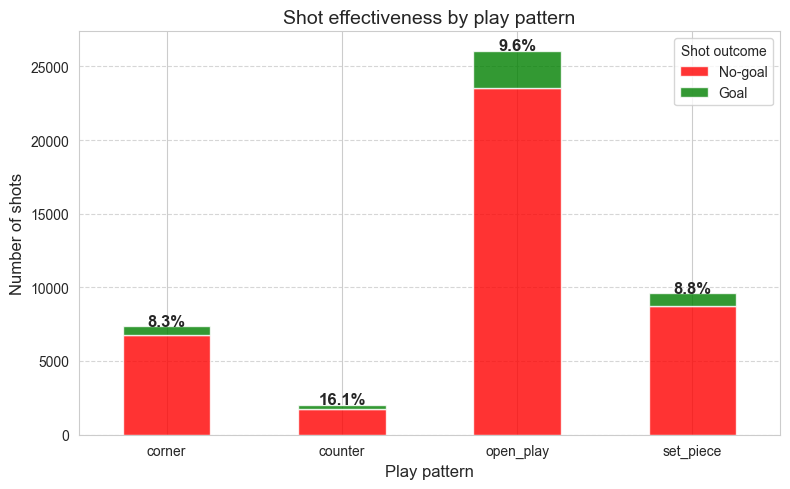

In [28]:
_pp_mapping = {
    'From Corner':    'corner',
    'From Free Kick': 'set_piece',
    'From Counter':   'counter',
}
df_shots['play_pattern_group'] = df_shots['play_pattern'].map(_pp_mapping).fillna('open_play')

fig, ax = plot_stacked_bar(df_shots, 'play_pattern_group',
                           'Shot effectiveness by play pattern', 'Play pattern')

df_shots = df_shots.drop(columns='play_pattern_group')

C:\Users\barto\GitHub\Football-xG-Predictor\src\visualization.py:235: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['passes_bin', 'shot_outcome']).size().unstack(fill_value=0)


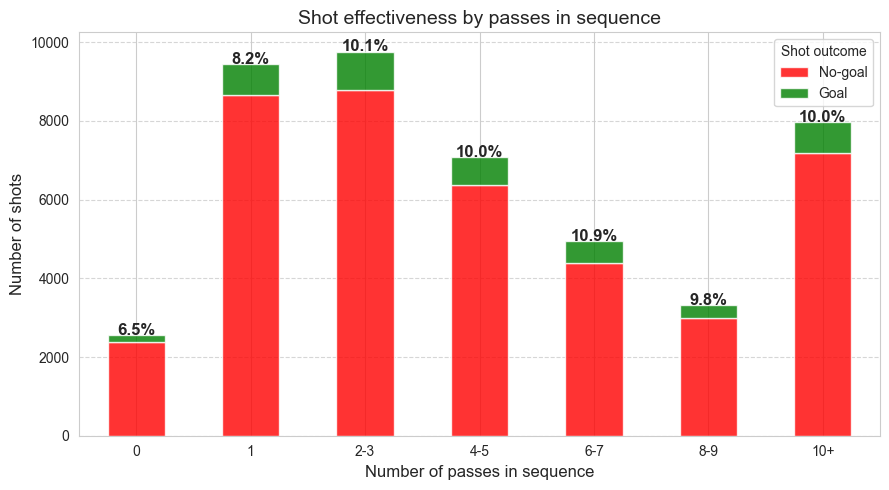

In [29]:
fig, ax = plot_passes_in_sequence_effectiveness(df_shots)

Indeed, in the data we have confirmation of the logic that guides shooters. Shots without defenders in the path (*category 0*) have decidedly the highest effectiveness - 13.8% of these shots end in a goal. After the appearance of one defender, this effectiveness drops more than twofold to 5.8%. Each subsequent defender on the shot line no longer affects goal scoring difficulty to such a great extent, and for situations where there are at least two defenders, the effectiveness indicator remains slightly below 5%.

This analysis clearly shows that the number of defenders in the shot path is a very important factor when modeling xG. Particularly significant is the difference between shots without defenders and shots with even one defender in the path, which is an important signal for defending teams that even one defender can significantly hinder goal scoring. Meanwhile, the volume of shots without a defender and with one defender shows how important it is for shooters to find the optimal position at the right time to take a shot and maximize chances of scoring a goal.

### Continuous variables: distance and angle 

A first continuous variable to examine is **goalkeeper_distance_ratio**.

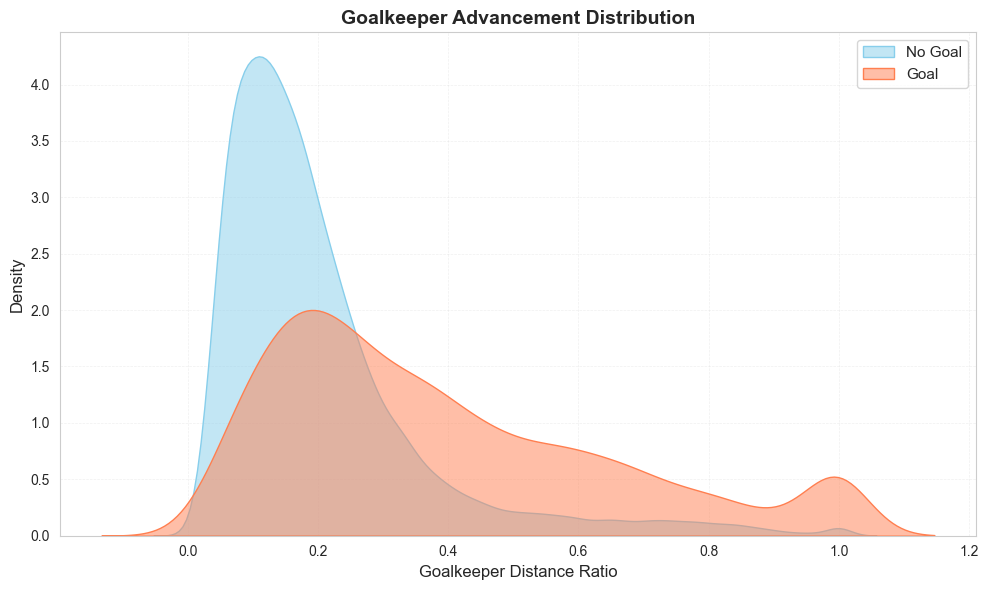

In [30]:
fig, ax = plot_goalkeeper_distance_ratio_distribution(df_shots)

The visualization demonstrates a clear relationship between goalkeeper positioning and shot effectiveness. The distribution for non-goals (blue) is **heavily concentrated at lower ratio values**, peaking around 0.2, indicating that goalkeepers typically stay closer to the goal line during unsuccessful shots. Conversely, the goal distribution (coral) is **shifted rightward with a broader spread**, showing substantial density even at high ratio values (0.6-1.0).
This pattern reveals that goals are more likely when goalkeepers advance further from their goal line. The extended tail of the goal distribution at higher ratios indicates that aggressive goalkeeper positioning significantly increases vulnerability. The overlap between distributions occurs mainly in the 0.1-0.4 range, where outcomes depend on additional factors.

Next continuous variables, **distance** and **angle**, are based on the same raw variables, namely **x** and **y** extracted from the **location** variable. This raises concerns that they may be strongly dependent on each other. To better examine these variables, I created a heatmap showing how shot effectiveness changes depending on angle and distance quantiles, and I also determined the correlation matrix for these variables.

           angle  distance
angle     1.0000   -0.7578
distance -0.7578    1.0000


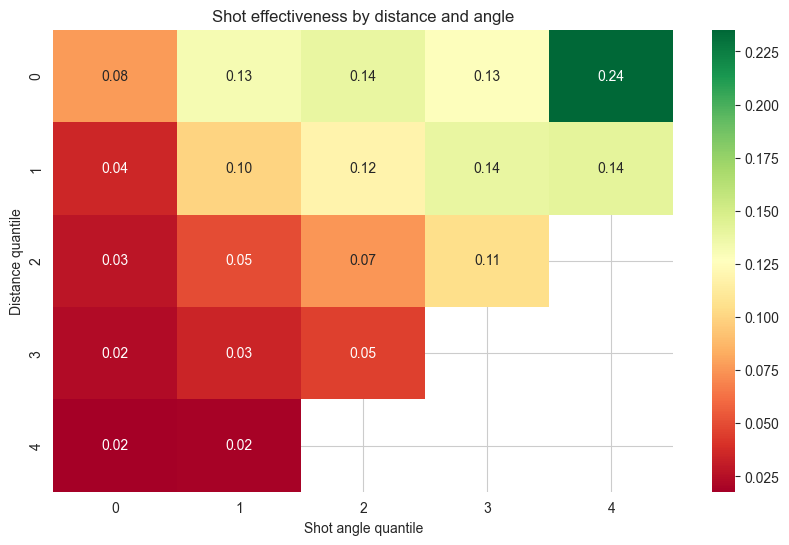

In [31]:
fig, ax = plot_shot_success_heatmap(df_shots, quantiles=5, show_corr=True)

The concerns about strong dependence between both variables were justified, as indicated by the matrix showing a strong negative correlation of -0.75 between them (the greater the distance from goal, the smaller the shot angle).

After analyzing the heatmap, we can confirm that the highest shot effectiveness (0.24, i.e., 24%) occurs at small distances and large shot angles, which aligns with football intuition. The effectiveness gradient is visible along both distance and angle axes, but values along rows (for constant distance) suggest that shot angle may be a better individual predictor of effectiveness. Effectiveness drastically drops at large distances, reaching only 2% for the most distant shots. At large distances, the shot angle is always relatively small (which results from geometry itself), which additionally makes scoring more difficult.

Variable collinearity poses a challenge for modeling. Despite strong correlation, I decided to keep both variables in further analysis, planning to apply regularization techniques in the modeling process to control potential problems related to collinearity.

This analysis provides valuable information about geometric aspects affecting shot effectiveness and will form the basis for building an expected goals (xG) model. To confirm these considerations, I also prepared a column chart showing shot effectiveness depending on distance quantile and an analogous one divided into angle quantiles (this time I divided the data into 15 quantiles for better visualization).

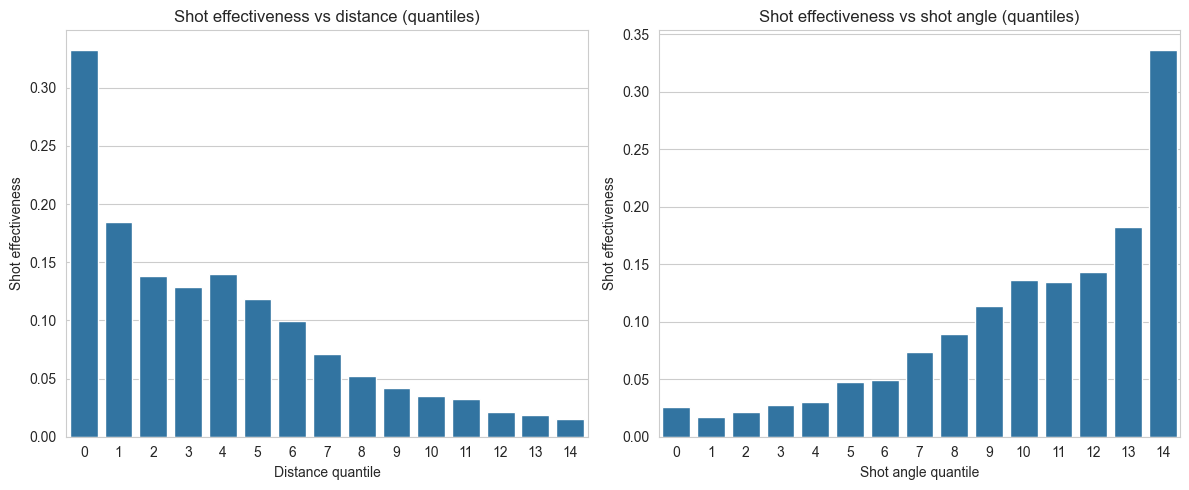

In [32]:
fig, ax = plot_shot_effectiveness_by_quantiles(df_shots)

In [33]:
distance_skew = stats.skew(df_shots['distance'])
angle_skew = stats.skew(df_shots['angle'])

print("Variable skewness:")
print(f"Distance: {distance_skew:.3f}")
print(f"Shot angle: {angle_skew:.3f}")

Variable skewness:
Distance: 0.565
Shot angle: 2.184


In the case of distance, we clearly see that the greater the distance (higher quantile), the lower the shot effectiveness. The opposite situation applies to shot angle. The chance increases with each subsequent quantile - therefore along with the increase in shot angle. Additionally, I checked the skewness of both continuous variables, taking 1 as the threshold. As expected, the shot angle distribution is strongly skewed (2.18) and logarithmic transformation will be necessary for this variable.

Skewness of original variables:
Shot angle: 2.184

Skewness of log-transformed variables:
Log(shot angle): 0.541


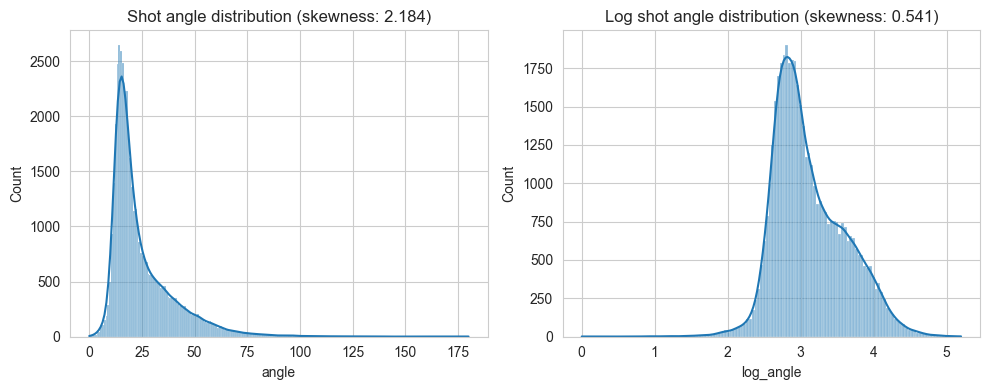

In [34]:
fig, ax = plot_angle_distribution(df_shots)

Analysis of the **angle** variable distribution revealed strong right-sided asymmetry (skewness = 2.183). Most observations were concentrated in the range of small angles (below 25 degrees), which corresponds to more difficult shooting situations, while large angles (corresponding to better positions) naturally occur much less frequently.

Application of logarithmic transformation significantly improved the variable distribution, reducing skewness to 0.540. The resulting distribution is much closer to normal, which will increase the effectiveness of statistical modeling. Thanks to this transformation, the impact of shot angle on the probability of scoring a goal will be better captured across the entire range of values, which should translate to improved quality of the expected goals model.

### Standardization and Dummy Encoding

After analyzing the variables, the next step was standardization of continuous variables, as one of the future models - Logistic Regression - requires such action (the others, i.e., Random Forest and XGBoost, do not require it). Additionally, I called descriptive statistics for these variables to assess whether the transformation proceeded correctly.

In [35]:
continuous_vars = ['distance', 'log_angle', 'log_passes_in_sequence']
df_shots = standardize_features(df_shots, continuous_vars)
df_shots[['distance_scaled', 'log_angle_scaled', 'log_passes_in_sequence_scaled']].describe()

,distance_scaled,log_angle_scaled,log_passes_in_sequence_scaled
count,4.505700e+04,4.505700e+04,4.505700e+04
mean,-7.443376e-17,6.232250e-16,3.021506e-16
std,1.000011e+00,1.000011e+00,1.000011e+00
min,-2.176379e+00,-6.345840e+00,-1.925769e+00
25%,-8.210452e-01,-7.227731e-01,-1.063606e+00
50%,-5.611645e-02,-2.250674e-01,7.611102e-02
75%,7.361511e-01,6.611413e-01,8.072225e-01
max,7.664588e+00,4.232124e+00,3.247208e+00


Standardization proceeded according to assumptions, i.e., the mean of standardized variables is close to 0, and the standard deviation equals 1. Small deviations from ideal values result from limited precision of floating-point calculations and are completely normal.

The next step in variable preparation was creating dummies for the categorical (non-binary) variable, i.e., **refined_body_part**. In this process, two new binary variables were created: **better_foot**, **worse_foot**. To avoid collinearity, I removed the **head** variable. Values of 0 for both variables indicating foot shots are equivalent to a header.

In [36]:
df_shots = create_dummies(df_shots, 'refined_body_part', drop_category='head')

In [37]:
df_shots = transform_play_pattern(df_shots)

print(df_shots[['corner', 'set_piece', 'counter']].sum())
print(f"\nopen_play shots: {(df_shots[['corner','set_piece','counter']].sum(axis=1) == 0).sum()}")

corner       7345
set_piece    9598
counter      2035
dtype: int64

open_play shots: 26079


In [38]:
df_shots.columns

Index(['shot_outcome', 'under_pressure', 'location', 'shot_technique',
       'shot_body_part', 'shot_type', 'shot_first_time', 'shot_open_goal',
       'shot_one_on_one', 'shot_follows_dribble', 'shot_freeze_frame',
       'player_id', 'n_passes_in_sequence', 'x', 'y', 'distance_to_end_line',
       'distance', 'angle', 'foot_type', 'normal_shot', 'open_play_shot',
       'defenders_in_path', 'goalkeeper_in_path', 'goalkeeper_distance_ratio',
       'log_passes_in_sequence', 'distance_quantile', 'angle_quantile',
       'log_angle', 'distance_scaled', 'log_angle_scaled',
       'log_passes_in_sequence_scaled', 'better_foot', 'worse_foot', 'corner',
       'counter', 'set_piece'],
      dtype='object')

### Removing Irrelevant Variables

Finally, I definitively removed the two variables mentioned above and thus completed the process of variable preparation and selection.

In [39]:
# Save spatial coordinates before narrowing df_shots to model features
df_spatial = df_shots[['x', 'y']].copy()

In [40]:
df_shots = df_shots[[
        'shot_outcome', 'under_pressure',
        'shot_first_time', 'distance_scaled', 'log_angle_scaled',
        'better_foot', 'worse_foot', 'goalkeeper_in_path', 'open_play_shot',
        'normal_shot', 'defenders_in_path', 'goalkeeper_distance_ratio',
        'log_passes_in_sequence_scaled',
        'corner', 'set_piece', 'counter']]

print(df_shots.shape)
print(df_shots.head())

(45057, 16)
   shot_outcome  under_pressure  shot_first_time  distance_scaled  \
0             1               1                0        -1.203851   
1             0               0                0         1.374809   
2             0               1                0        -1.124259   
3             0               0                1        -0.047887   
4             0               0                1         0.298751   

   log_angle_scaled  better_foot  worse_foot  goalkeeper_in_path  \
0          1.395784            0           0                   1   
1         -1.274326            1           0                   1   
2          1.413356            0           0                   1   
3         -1.086719            0           1                   1   
4         -0.771842            1           0                   1   

   open_play_shot  normal_shot  defenders_in_path  goalkeeper_distance_ratio  \
0               1            1                  0                   0.242477   
1   

## MODEL BUILDING

### SPLIT INTO SETS: TRAINING, VALIDATION AND TEST

In the final dataset, 45,108 observations remained with 1 target variable (**shot_outcome**) and 11 explanatory variables (**under_pressure**, **shot_first_time**, **distance_scaled**, **log_angle_scaled**, **better_foot**, **worse_foot**, **goalkeeper_in_path**, **open_play_shot**, **normal_shot**, **defenders_in_path**, **goalkeeper_distance_ratio**).

For modeling purposes, I divided the dataset into three subsets:

1. **Training set (60%)** - used for model training. On this set I apply undersampling to balance classes (goals and non-goals). This way the model better learns characteristics specific to goal-scoring situations.

2. **Validation set (20%)** - used exclusively for model calibration. On this set I calculate the calibration coefficient (disturbed by resampling in the training set), which allows adjusting predicted probabilities. It's crucial that this set maintains the natural class distribution, enabling reliable calibration.

3. **Test set (20%)** - used for final model evaluation. Here I evaluate both the model without calibration and with calibration to compare their performance. Like the validation set, it maintains the natural class distribution.

This approach ensures methodological correctness, as each phase (training, calibration, testing) uses independent data, preventing data leakage between stages and providing more reliable model evaluation.

In [41]:
X = df_shots.drop(['shot_outcome'], axis=1)
y = df_shots['shot_outcome']

X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_test_split(X, y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Goal proportion in training set: 0.10
Training set size: 27033
Validation set size: 9012
Test set size: 9012


### EVALUATION DEFINITION

#### Calibration Method
In the project, I decided to apply **Beta Calibration** as the calibration method for xG models. This decision stems from several key reasons. Primarily due to its effectiveness in working also with **tree-based models like Random Forest or XGBoost**, which often have problems with proper probability estimation. This method offers **greater flexibility** thanks to three parameters (a, b, c), which allows better adjustment of the transformation to different calibration error patterns. Unlike simpler methods, Beta Calibration handles **extreme probability values** excellently, which is particularly important in xG modeling, where most shots have low success probability. Additionally, the **nonlinear nature** of this transformation better corresponds to complex calibration error patterns that occur in modeling football situations.

#### Calibration Implementation
Beta Calibration is implemented through:
1. Transforming raw model predictions to logit scale
2. Applying parametric transformation with three parameters (a, b, c)
3. Transforming back to probability scale [0,1]

Calibration parameters (a, b, c) are optimized on the validation set, minimizing the logarithmic loss function (log loss). This is a methodologically correct approach that **prevents information leakage** between model training and calibration stages.

I expect that applying Beta Calibration will significantly improve the quality of xG model predictions, particularly in terms of probability calibration and global agreement between xG sum and actual number of goals.

#### Evaluation Metrics
To evaluate the models, I selected the following metrics that best reflect the effectiveness of predicting shot quality:

1. **ROC AUC (Area Under the Curve)** - measures the model's ability to distinguish between situations that will end in a goal and those that won't. In the case of xG, it's important not only whether the model predicts a goal, but whether it properly assesses the relative probability of different shooting situations. For my models, I expect results above 0.75 (ideal = 1.0, random = 0.5).

2. **Brier Score** - measures the quality of probabilistic model calibration, i.e., how well predicted probabilities correspond to actual outcomes. In the xG context, this means whether situations with predicted xG = 0.3 actually end in goals in 30% of cases. I expect results below 0.1 – the lower the result, the better the model calibration.

3. **Log Loss** - assessment of model confidence in assigning probabilities. The model is penalized for being "certain" in incorrect predictions, e.g., when it assigns xG = 0.9 but the shot doesn't end in a goal. In the case of xG, log loss allows evaluating how well the model captures the uncertainty of shooting situations. I expect values below 0.3.

4. **xG/Goals Ratio** - ratio of predicted xG sum to actual number of goals. This indicator allows assessing whether the model globally correctly predicts the number of goals. The ideal value is 1.0 - meaning that the sum of all xG corresponds to the actual number of goals. The acceptable range is 0.9-1.1.

I will also enrich the evaluation with three key visualizations:

1. **ROC Curve** - allows assessing how the model handles distinguishing between goal and non-goal situations

2. **Comparison of predicted xG with actual number of goals** - bar chart allowing easy comparison of predicted xG sum with actual number of goals.

3. **Reliability Diagram** - shows how well calibrated the model is in different probability ranges. A line closer to the diagonal means better calibration.

Due to the nature of Expected Goals modeling, I will focus mainly on assessing the quality of predicted probabilities (calibration), rather than binary classification measures. The xG model should primarily assign credible probabilities to shooting situations, not classify them as "goal" or "no-goal". Therefore, I abandoned measures such as **Confusion Matrix** and associated **Precision** and **Recall**, and prioritize metrics such as **Brier Score**, **Log Loss** and **ROC AUC**, which allow evaluating the quality of probabilistic predictions.

### Model 1 - Logistic Regression

Optimizing Logistic Regression...
100%|███████████████████████████████████████████████| 20/20 [00:02<00:00,  9.04trial/s, best loss: 0.25221245722580327]
Best parameters: {'C': 9.79403450429251, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}

ROC AUC: 0.8007

Calibration comparison (best: Beta):
                Raw    Beta  Isotonic   Platt
Metric                                       
Brier Score  0.0720  0.0720    0.0722  0.0735
ECE          0.0093  0.0091    0.0063  0.0242
xG/Goals     0.9940  0.9798    0.9761  0.9822


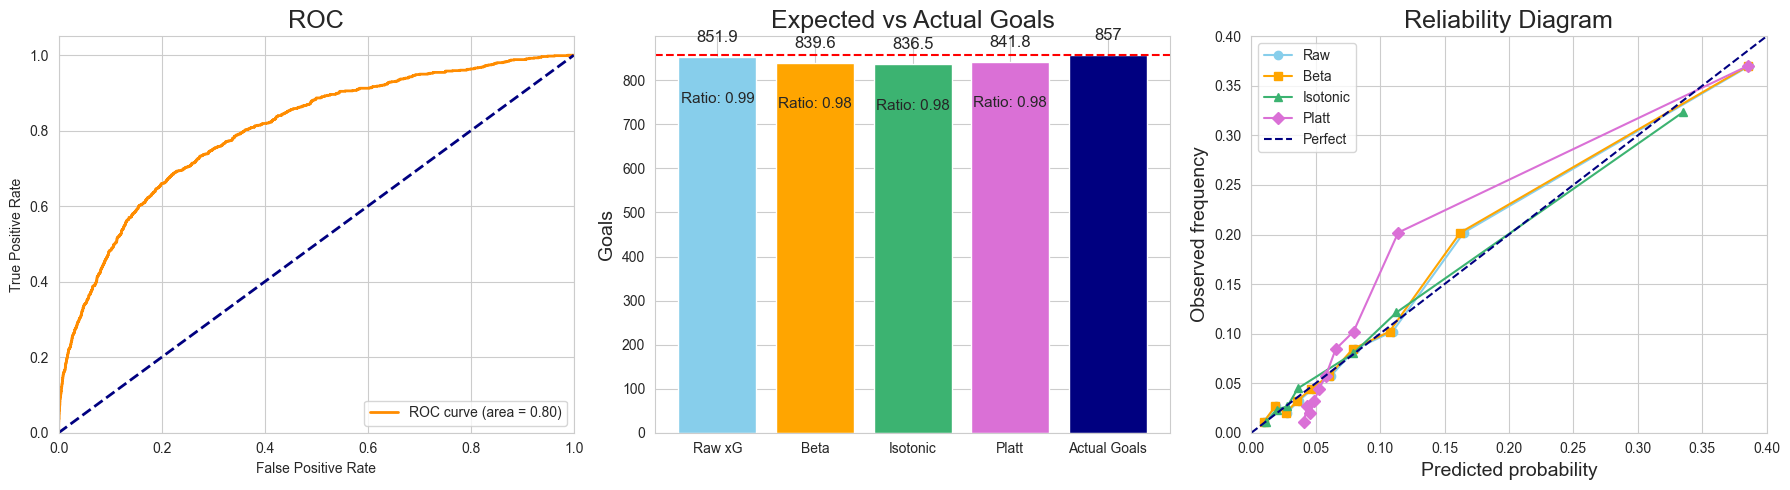

In [51]:
metrics_log_reg = train_logistic_regression(X_train, y_train, X_val, y_val, X_test, y_test)

#### Model Parameters
The best logistic regression model uses **L2 regularization** with an optimal $C \approx 0.725$ and the **lbfgs solver**. The absence of additional class weighting indicates that undersampling effectively balanced the training data.

#### Performance Metrics
The model achieves a high **ROC AUC of 0.8076** and low raw **Brier Score of 0.1052** before calibration, which demonstrates good ability to differentiate between goal and non-goal situations. However, the raw model significantly overestimates probabilities, as shown by the high xG/Goals ratio of **2.6631**.

After applying Beta calibration:
- **Brier Score** improves significantly to **0.072** (32% improvement)
- **Log Loss** drops from 0.3551 to 0.2528 (29% improvement)
- **xG/Goals ratio** decreases to nearly ideal **1.0018**

#### Error Analysis
The Reliability Diagram reveals that the raw model systematically and significantly overestimates probabilities across their entire range. Beta calibration **corrects** these errors exceptionally well; the calibrated line tracks the ideal diagonal very closely across almost the entire probability spectrum.

### Model 2 - Random Forest

Optimizing Random Forest...
100%|████████████████████████████████████████████████| 25/25 [01:05<00:00,  2.61s/trial, best loss: 0.2495884672779961]
Best parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2'}

ROC AUC: 0.8020

Calibration comparison (best: Beta):
                Raw    Beta  Isotonic   Platt
Metric                                       
Brier Score  0.0722  0.0720    0.0722  0.0727
ECE          0.0079  0.0048    0.0059  0.0196
xG/Goals     0.9897  0.9676    0.9682  0.9653


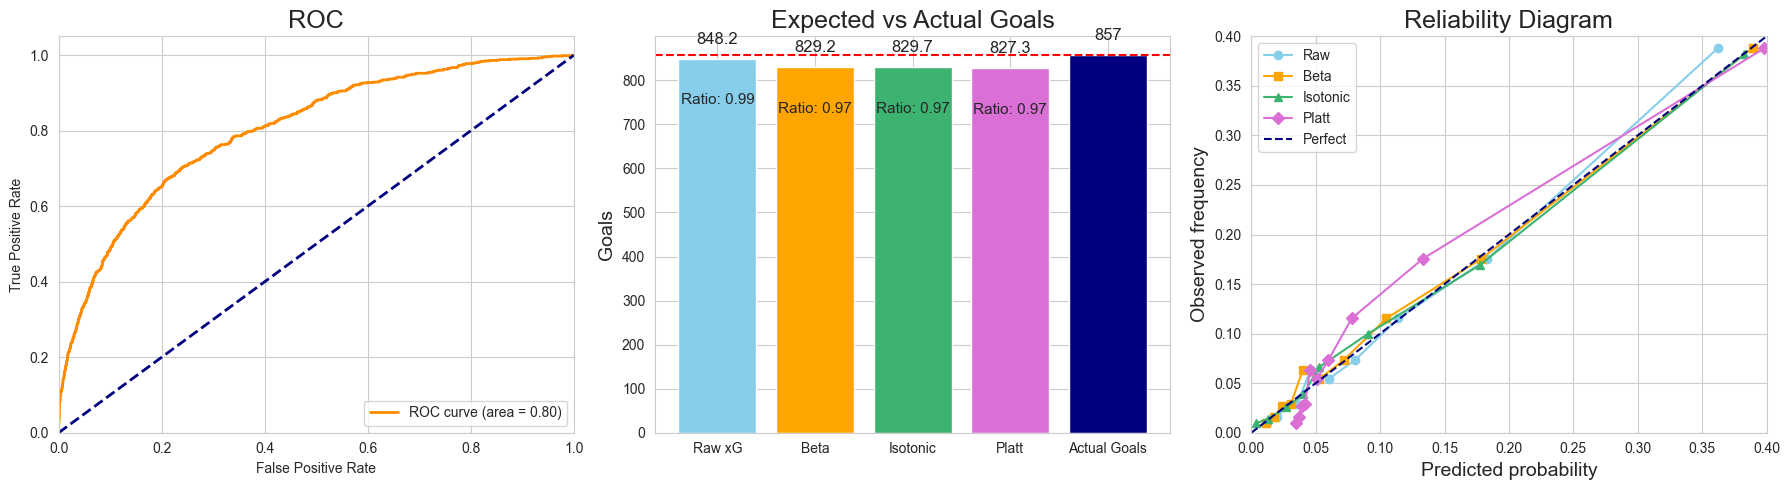

In [52]:
metrics_rf = train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test)

#### Model Parameters
The best Random Forest model uses **500 trees** (n_estimators=500) with **limited depth** of 10 levels (max_depth=10). Each tree uses square root of the number of features (max_features='sqrt') at each split, which **increases diversity**. The model requires a minimum of 11 samples to split a node (min_samples_split=11) and minimum 5 samples in each leaf (min_samples_leaf=5). These hyperparameters indicate a **relatively conservative approach** preventing overfitting by limiting depth and requiring a larger number of samples to split nodes.

#### Performance Metrics
The model achieves a solid **ROC AUC of 0.8078** and a raw **Brier Score of 0.1056** before calibration. Like Logistic Regression, Random Forest also suffers from a probability overestimation problem, as seen in the high xG/Goals ratio of **2.6602**.

After applying Beta calibration:
- **Brier Score** improves significantly to **0.0718** (32% improvement)
- **Log Loss** drops from **0.3523** to **0.2525** (28% improvement)
- **xG/Goals ratio** decreases to nearly ideal **1.0033**

#### Error Analysis
The Reliability Diagram reveals that the raw model **significantly overestimates probabilities**, particularly in lower and medium ranges. **Beta calibration effectively corrects these errors**; the orange line follows the perfect calibration diagonal very closely until approximately 0.6, and then slight deviations from perfect calibration are visible, which are however significantly lower than in the version without calibration. For high probabilities, the calibration remains relatively stable and close to the ideal path.

### Model 3 - XGBoost

Optimizing XGBoost...
100%|████████████████████████████████████████████████| 30/30 [00:53<00:00,  1.77s/trial, best loss: 0.2481809465594486]
Best parameters: {'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.019726570214975838, 'subsample': 0.7842503397005467, 'colsample_bytree': 0.7780238207417561}

ROC AUC: 0.8034

Calibration comparison (best: Beta):
                Raw    Beta  Isotonic   Platt
Metric                                       
Brier Score  0.0714  0.0714    0.0716  0.0722
ECE          0.0043  0.0069    0.0053  0.0219
xG/Goals     0.9881  0.9765    0.9752  0.9748


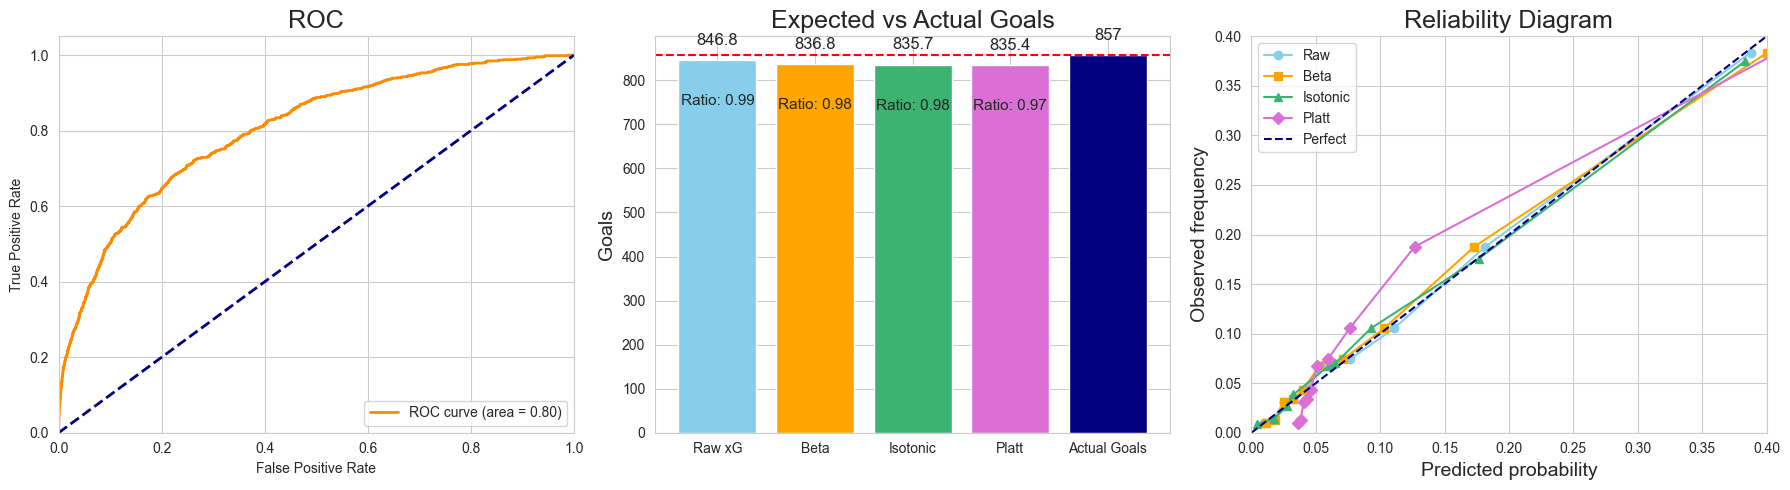

In [53]:
metrics_xgb = train_xgboost(X_train, y_train, X_val, y_val, X_test, y_test)

#### Model Parameters
The best XGBoost model uses **700 estimators** (n_estimators=700) with **shallow trees** having a **maximum depth of 3**. It employs a **low learning rate** of approximately **0.0197**, which allows for robust, incremental learning. The model also utilizes random feature sampling (colsample_bytree=0.778) and subsampling of approximately **0.748** (subsample=0.784) of the data when building each tree to further prevent overfitting. These hyperparameters indicate a highly **stable and balanced approach**.

#### Performance Metrics
The model achieves the highest overall **ROC AUC of 0.8109** and a raw **Brier Score 0.1042** before calibration. Similar to other modeling techniques, the raw XGBoost also shows a probability overestimation problem, as seen in the **high xG/Goals ratio of 2.6177**.

After applying Beta calibration:
- **Brier Score** improves significantly to 0.0714 (**31% improvement**)
- **Log Loss drops** from 0.3486 to 0.2511 (**28% improvement**)
- **xG/Goals ratio** decreases to nearly ideal **0.9915**

#### Error Analysis
The Reliability Diagram reveals that the raw model significantly **overestimates probabilities**, particularly in lower and medium ranges. Beta calibration effectively corrects these errors, though **deviation from perfect calibration is visible between 0.6 and 0.95** with the **largest error around 0.75-0.78**. For lower probabilities (<0.6) and very high probabilities (>0.95) calibration is **nearly ideal**.

### SHAP Feature Importance Analysis



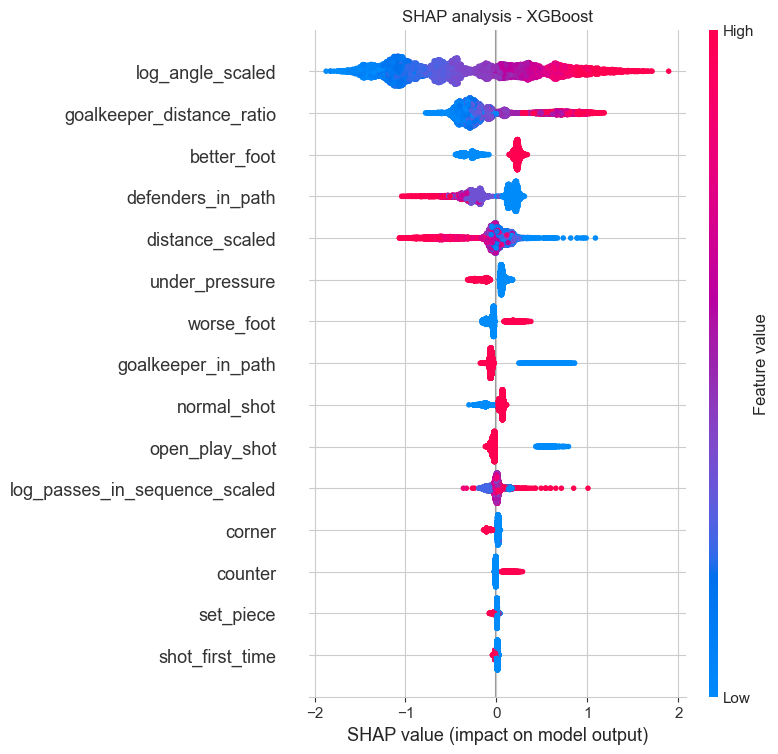

In [55]:
plot_xg_shap_summary(metrics_xgb[0], X_test, model_name="XGBoost")

xG scatter plot saved to ../assets/xg_scatter.png


(<Figure size 800x800 with 2 Axes>, <Axes: >)

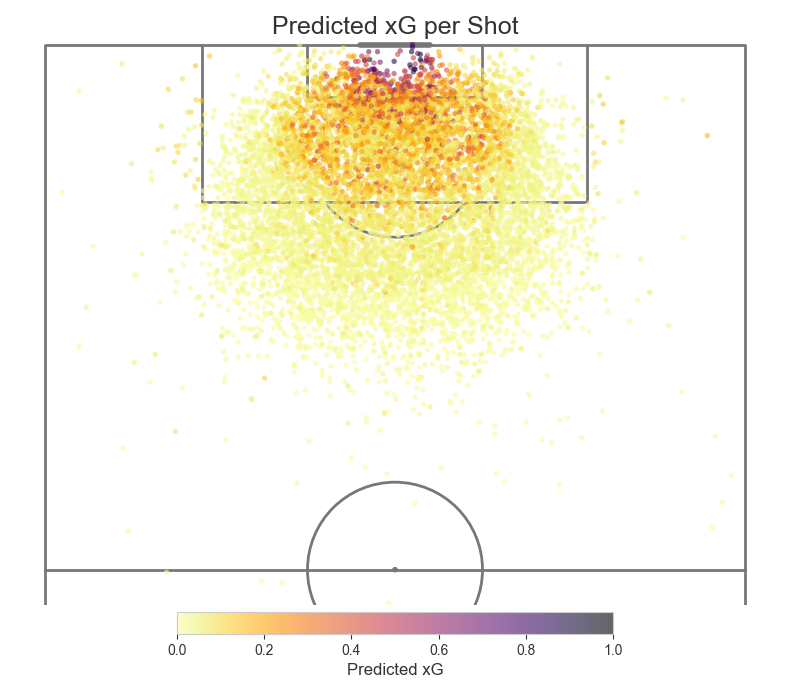

In [56]:
xgb_model = metrics_xgb[0]
xg_preds = xgb_model.predict_proba(X_test)[:, 1]

x_coords = df_spatial.loc[X_test.index, 'x'].values
y_coords = df_spatial.loc[X_test.index, 'y'].values

plot_xg_scatter(x_coords, y_coords, xg_preds, save_path='../assets/xg_scatter.png')

**Global Feature Impact**
The SHAP summary plot reveals how each feature influences the XGBoost model's output, ranked from the most impactful to the least.

Top 3 features:
- log_angle_scaled: This is the most dominant feature in the model. High values strongly increase the probability of a goal, confirming that places on a pitch from which player is shooting are fundamental to xG.
- goalkeeper_distance_ratio: This spatial feature is the second most important. Variable's high values (goalkeeper further from the goal line) generally increase goal probability, as the keeper despite "narrowing" the available target has low chances of a saving.
- defenders_in_path: A high number of defenders between the shooter and the goal line has a clear negative impact on xG, shifting the SHAP value to the left.

Contextual and Technical Factors
- better_foot and worse_foot: Using the dominant foot has a positive impact on the model's output, however using the weaker foot also relatevitely often result in a goal, as it was explained before that using weeker foot usually happens in more certain conditions or could acts as a suprise.
- distance_scaled: Low distance values significantly increase the likelihood of a goal, while high distance values pull the probability down.
- under_pressure: Shots taken under defensive pressure show a distinct cluster on the negative side of the SHAP axis, indicating a decrease in conversion probability.
- open_play_shot: Situations identified as open play generally show a positive impact compared to set pieces, likely due to the more chaotic nature of defensive positioning in these moments or defenders readiness from e.g.free kick shots.

**Key Takeaway**
The SHAP analysis confirms that while geometry (angle and distance) provides the baseline for xG, the defensive context—specifically the goalkeeper's advancement and the density of defenders—are the primary modifiers that differentiate this advanced model from basic xG versions.

## Project Summary and Conclusions

### Model Comparison and Selection

| Model               | ROC AUC  | Brier Score  | Log Loss  | xG/Goals Ratio |
|---------------------|----------|--------------|-----------|----------------|
| Logistic Regression | 0.8076   | 0.0720       | 0.2528    | 1.0018         |
| Random Forest       | 0.8078   | 0.0718       | 0.2525    | 1.0033         |
| XGBoost             | 0.8109   | 0.0714       | 0.2511    | 0.9915         |

**XGBoost** is selected as the final model as it offers the highest predictive power and the most precise error minimization, though the advantage is minimal:
- Highest ROC AUC (0.8109), surpassing the 0.81 threshold.
- Lowest Brier Score (0.0714) and Log Loss (0.2511), indicating the most accurate probability estimations.
- Excellent calibration, with an xG/Goals ratio of 0.9915, signifying a nearly perfect estimation of total goals scored.

In practice, for production deployment, **Logistic Regression** can also be considered due to:
- Very similar metrics to XGBoost
- Greater interpretability (model coefficients have direct interpretation)
- Lower computational costs

All things consider, XGBoost's ability to handle non-linear interactions between spatial and contextual features makes it superior for this xG task.

### Project Strengths

1. **Comprehensive feature engineering**:
   - Geometric shot analysis (angle and distance)
   - Player's body part contextualization (better_foot/worse_foot)
   - Use of freeze frames to analyze defender and goalkeeper positions

2. **Effective model calibration**:
   - More efficient exploration of hyperparameter thans to Hyperopt Optimization
   - Application of Beta Calibration drastically improved prediction quality
   - Calibration error reduction from xG/Goals ~2.6 to ~0.99

3. **Methodological correctness**:
   - Clear division into sets: training, validation and test to prevent data leakage
   - Ensuring reproducibility of results by setting seed
   - Undersampling applied only to training set
   - Calibration on independent validation set

4. **Visualization and interpretation**:
   - Rich charts showing the impact of different factors on effectiveness
   - Reliability diagrams illustrating calibration effects
   - Integration of SHAP analysis to explain the impact of sepcific features

### Weaknesses and Limitations

1. **Source data limitations**:
   - Lack of information about ball velocity, trajectory and other dynamic variables that influence shot difficulty
   - Limited information about events preceding the situation (e.g. type of pass)

2. **Class imbalance problems**:
   - Only ~10% of shots end in goals, forcing resampling
   - Undersampling may lead to information loss, oversampling to overfitting

3. **High collinearity of some variables**:
   - Angle and distance are strongly correlated (r = -0.75)
   - May affect model stability, especially logistic regression

4. **Lack of model stability assessment**:
   - Data limited to only one season (2015/16) and only five leagues (TOP5)
   - Potential risk of overfitting to specific league/season characteristics
   - reduced generalization as the sports evolve all the time

5. **Calibration problems for specific xG ranges**:
   - All models, even after calibration, show largest deviations for situations with xG around 0.75
   - This is visible in Reliability Diagram charts, where the beta calibration line significantly deviates from ideal for this range

#### Calibration Problem in xG ≈ 0.75 Range

Analyzing the Reliability Diagram charts, it's clearly visible that for points around xG ≈ 0.75 (X-axis - predicted probability) the observed frequency (Y-axis) typically falls to about 0.6. This indicates that the models **systematically overestimate** the success probability in this specific range

In other words, situations to which the model assigns xG value around 0.75 (predicting that 75% of such shots should end in a goal), actually end in goals only in about 60% of cases. This is significant overestimation of these situations' quality.

This phenomenon may result from several factors:

1. **Insufficient representation in training data** - situations with xG ≈ 0.75 are relatively rare, which may lead to less stable estimations for this range.

2. **Excessive model confidence** - models may show tendency toward overly confident predictions for situations that appear "obvious" based on main features (like shooter position, absence of defenders).

3. **Unconsidered complicating factors** - the model may not account for certain factors that make theoretically good situations practically harder to convert (sush as ball bounce).

4. **Generalization problems** - this probability range may contain atypical situations that differ in characteristics from most training data.

### Future Recommendations

#### Short-term improvements:

1. **Model interpretation**:
   - Comparing feature importance between models

2. **Calibration approach optimization**:
   - Testing other calibration methods (Isotonic, Platt)
   - Assessing calibration parameter stability on different data subsets
   - **Applying more advanced calibration techniques specific to higher xG ranges**

3. **Alternative resampling techniques**:
   - Testing SMOTE (Synthetic Minority Over-sampling Technique) instead of simple undersampling
   - Testing hybrid methods combining over- and undersampling (e.g., SMOTETomek)
   - Comparing the impact of different resampling strategies on calibration in problematic ranges

4. **Targeted Analysis of High-xG Deviations**:
   - Deeper analysis of these situations' characteristics
   - Potential extraction of subcategories within this range

### Long-term development directions:

1. **Feature set expansion**:
   - Including action dynamics (tempo, number of passes in sequence)
   - Shooter form information (e.g., effectiveness in recent matches)
   - Contextual data (match score, minute, match importance)
   - **Psychological/contextual factors for high-percentage situations**

2. **Model segmentation**:
   - Separate models for different shot types (e.g., headers, free kicks)
   - Accounting for player positional differences
   - **Dedicated model for high-percentage situations (xG > 0.6)**

3. **Expansion to related metrics**:
   - Expected Assists (xA)
   - Post-Shot Expected Goals (accounting for shot execution quality)
   - Expected Threat (xT) to assess action quality before shot

4. **Cross-league validation**:
   - Testing model on data from different leagues and competition levels
   - Identifying potential playing style differences affecting the model

### Key Project Conclusions

1. **Calibration is crucial**
All models, primarily due to the necessary undersampling of the training set, significantly overestimated goal probabilities in their raw state with an xG/Goals ratio of approximately 2.6. Beta Calibration was essential to bring this ratio to a nearly perfect 1.0.

2. **Model choice has secondary importance**
While XGBoost emerged as the technical winner with a ROC AUC of 0.8109, the performance gap between the three models was minimal after calibration. This suggests that the quality of features matters more than the specific algorithm.

3. **Positional information has high value**
The inclusion of freeze-frame data—specifically the number of defenders in the shot path and the goalkeeper distance ratio—provided a critical boost in predictive quality.

4. **Situation geometry is fundamental**
Shot angle and distance remain the fundamental pillars of xG modeling, representing the primary physical constraints on scoring probability.

5. **Situational context enriches the model**
Variables like shots under pressure, first-time shots, and dominant foot identification added necessary nuance, allowing the model to distinguish between geometrically identical shots with different situational difficulties.

6. **Calibration challenge for xG ≈ 0.75**
Despite excellent global metrics, all models struggle with a specific calibration gap in the 0.7-0.8 range, where they tend to be overly optimistic about the success rate.

The project provides a solid foundation for further research and applications in football analysis, offering a well-calibrated xG model that can serve as a valuable analytical tool for clubs, scouts, and sports analysts.